In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import os
import sys

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('train.csv')
df.head()

,Unnamed: 0,clean_title,id,2_way_label,image_path
0,0,i took apart an air jordan and put it back but...,bi4p6x,1,images/bi4p6x.jpg
1,1,napoleon leads his troops against king arthur ...,8p7ji4,0,images/8p7ji4.jpg
2,2,fat orangutan,5iiry6,1,images/5iiry6.jpg
3,3,while remodeling i pulled down part of the cei...,ci5kf5,1,images/ci5kf5.jpg
4,4,a very relaxed cat,1hvpun,1,images/1hvpun.jpg


In [3]:
df.shape

(11174, 5)

In [4]:
df[df['image_path'].isna()]  

,Unnamed: 0,clean_title,id,2_way_label,image_path


In [5]:
df = df.dropna(subset=['image_path'])

In [6]:
def is_valid_image(path):
    try:
        if not os.path.exists(path):
            return False
        if os.path.getsize(path) == 0:
            return False
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

# Check how many are invalid before removing
invalid = ~df['image_path'].apply(is_valid_image)
print(f"Invalid/empty images found: {invalid.sum()}")

# Remove invalid rows
df = df[~invalid].reset_index(drop=True)
print(f"Remaining rows: {len(df)}")

Invalid/empty images found: 7
Remaining rows: 11167


2_way_label
0    5009
1    6158
Name: count, dtype: int64


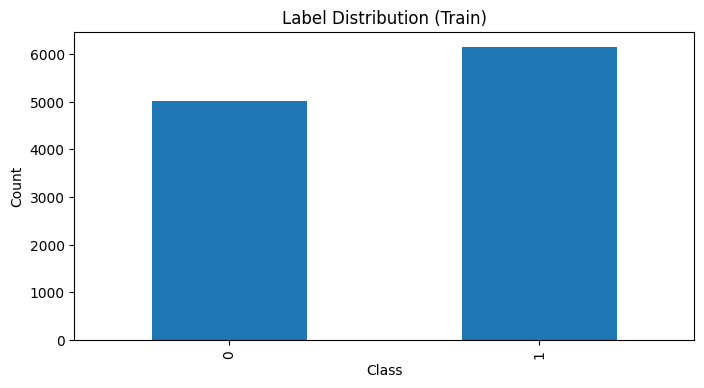

In [7]:
label_counts = df["2_way_label"].value_counts().sort_index()

print(label_counts)

plt.figure(figsize=(8,4))
label_counts.plot(kind="bar")
plt.title("Label Distribution (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

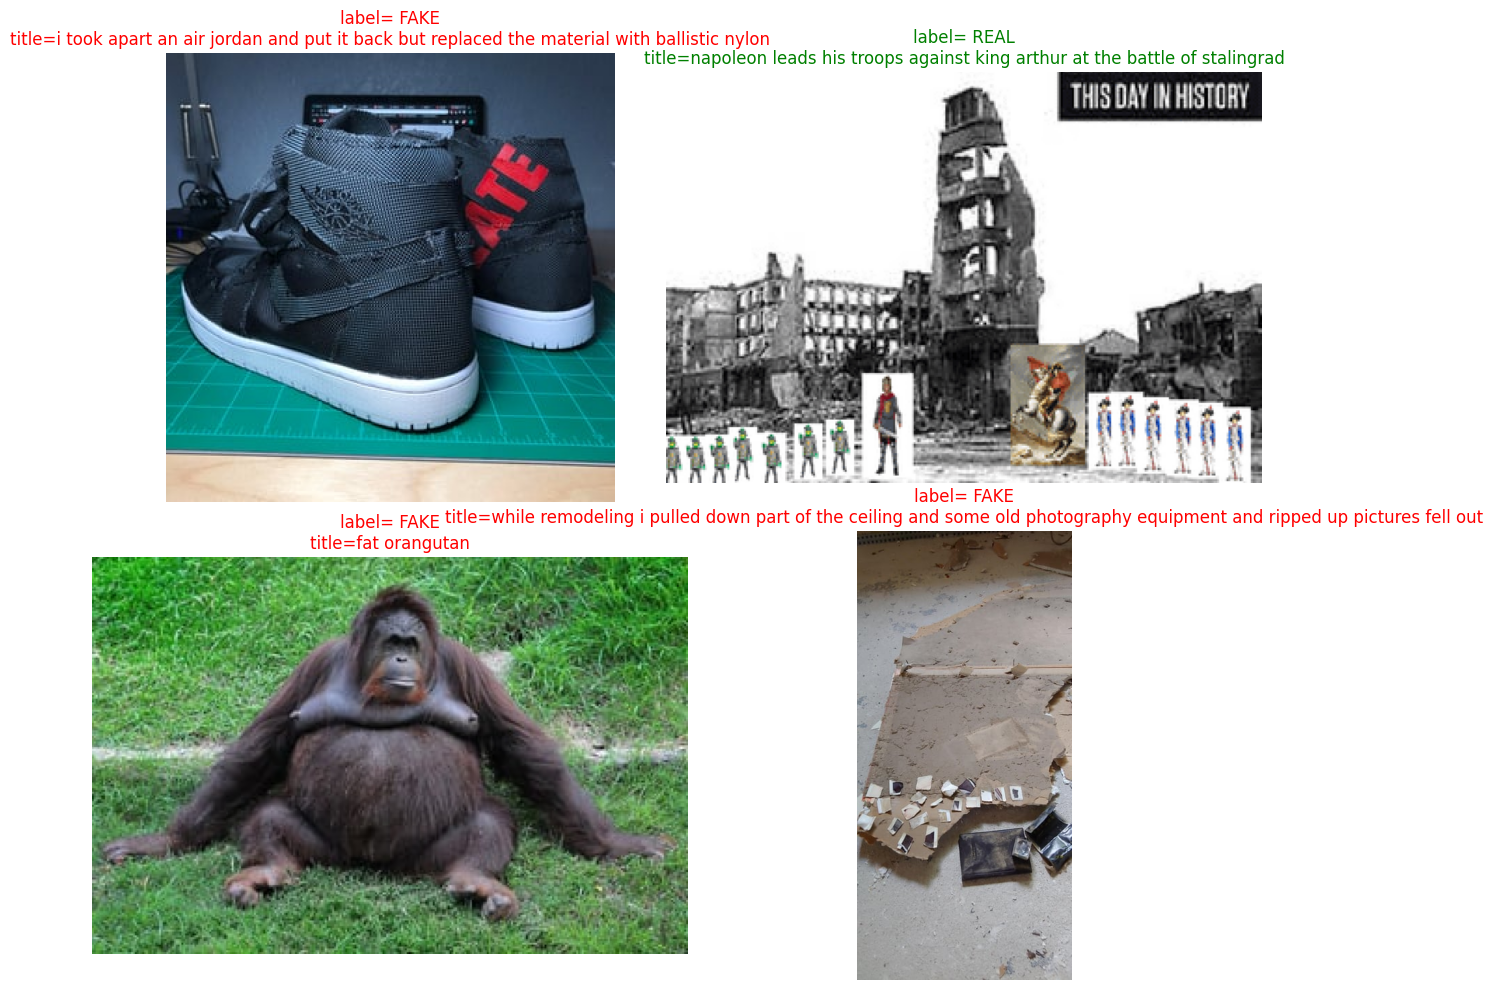

In [8]:
ok_samples = df.head(4)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(ok_samples.iterrows(), start=1):
    img = Image.open(row["image_path"])
    plt.subplot(2, 2, i)
    plt.imshow(img)
    if row["2_way_label"] == 0:
        plt.title(f"label= REAL\ntitle={row['clean_title']}",color="green")
    else:
        plt.title(f"label= FAKE\ntitle={row['clean_title']}",color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as f
from torch.optim import AdamW

import torchvision
from torchvision.transforms import v2
from torchvision.models import resnet50, ResNet50_Weights
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import BertTokenizer, BertModel
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torchvision.models as models
import time 
import seaborn as sns

import random

In [10]:
df[df['image_path'].isna()]     # Returns filtered DataFrame

,Unnamed: 0,clean_title,id,2_way_label,image_path


In [11]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["2_way_label"])
print(f"Train set size: {len(df_train)}, Test set size: {len(df_test)}")

Train set size: 8933, Test set size: 2234


In [12]:
df_test,df_val = train_test_split(df_test, test_size=0.3, random_state=42, stratify=df_test["2_way_label"])
print(f"Test set size: {len(df_test)}, Validation set size: {len(df_val)}")

Test set size: 1563, Validation set size: 671


In [13]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [14]:
df_train.head()

,Unnamed: 0,clean_title,id,2_way_label,image_path
0,2656,no jail time for yearold in idaho coathanger a...,5xqcfl,1,images/5xqcfl.jpg
1,7597,us officials declare green sea turtles of flor...,4f8a02,1,images/4f8a02.jpg
2,9455,the text on the car is flipped so you can read...,9hktmy,1,images/9hktmy.jpg
3,3467,mcmaster says donald trumps soninlaw and a ter...,8s8a2c,0,images/8s8a2c.jpg
4,10512,update letters supporting homosexual lifestyle...,2uu2pn,1,images/2uu2pn.jpg


In [15]:
df_train[df_train['image_path'].isna()]     # Returns filtered DataFrame   # Returns True/False

,Unnamed: 0,clean_title,id,2_way_label,image_path


In [16]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),  # Crop the center to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MyMultimodalDataset(Dataset):
    def __init__(self, image_paths, description, label, transform=None):
        self.image_paths = image_paths
        self.description = description
        self.label = label
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        text = self.description[idx]
        label = self.label[idx]
        #print(img_path)
        
        # Ensure img_path is a string
        if not isinstance(img_path, str):
            raise ValueError(f"Invalid image path at index {idx}: {img_path}")
        # Load and preprocess image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        return image, text, label

In [17]:
train_dataset = MyMultimodalDataset(df_train['image_path'], df_train['clean_title'], df_train['2_way_label'], transform=transform)
val_dataset = MyMultimodalDataset(df_val['image_path'], df_val['clean_title'], df_val['2_way_label'], transform=transform)
test_dataset = MyMultimodalDataset(df_test['image_path'], df_test['clean_title'], df_test['2_way_label'], transform=transform)

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [19]:
resnet50 = models.resnet50(weights='IMAGENET1K_V1', progress=True)
resnet50 = torch.nn.Sequential(*(list(resnet50.children())[:-1]))

In [20]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
bert_model = BertModel.from_pretrained("bert-base-multilingual-cased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
resnet50.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [22]:
bert_model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [23]:
from tqdm import tqdm
import torch.optim as optim

In [24]:
optimizer = AdamW(list(resnet50.parameters()) + list(bert_model.parameters()), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()

In [25]:
class CombinedClassifier(nn.Module):
    def __init__(self, img_feature_dim, text_feature_dim, num_classes):
        super(CombinedClassifier, self).__init__()
        self.img_fc = nn.Sequential(
            nn.Linear(img_feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self.text_fc = nn.Sequential(
            nn.Linear(text_feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, img_features, text_features):
        img_logits = self.img_fc(img_features)
        text_logits = self.text_fc(text_features)
        combined_logits = 0.5 * (img_logits + text_logits)  # Simple averaging
        return combined_logits


# Example usage assuming img_feature_dim is correctly set
combined_classifier = CombinedClassifier(img_feature_dim=2048, text_feature_dim=768, num_classes=2).to(device)

# Define optimizer and criterion
optimizer = optim.AdamW(list(resnet50.parameters()) + list(bert_model.parameters()) + list(combined_classifier.parameters()), lr=1e-5)
criterion = nn.CrossEntropyLoss()

In [26]:
num_epochs = 15
max_seq_length = 80

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    resnet50.train()
    bert_model.train()
    combined_classifier.train()
    
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, texts, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=False):
        # Move tensors to the device
        images = images.to(device)
        labels = labels.to(device)

        # Extract image features using resnet50
        with torch.no_grad():
            img_feats = resnet50(images)
        
        # Reshape img_feats
        img_feats = img_feats.view(img_feats.size(0), -1)

        # Convert texts to tensors and pad to a fixed sequence length
        texts = [bert_tokenizer(text, padding='max_length', truncation=True, max_length=max_seq_length, return_tensors='pt') for text in texts]
        input_ids = torch.stack([text['input_ids'].squeeze(0) for text in texts], dim=0).to(device)
        attention_mask = torch.stack([text['attention_mask'].squeeze(0) for text in texts], dim=0).to(device)

        optimizer.zero_grad()

        outputs = bert_model(input_ids, attention_mask=attention_mask)
        text_feats = outputs.last_hidden_state[:, 0, :]

        # Early fusion: concatenate raw image and text features
        combined_logits = combined_classifier(img_feats, text_feats)

        # Ensure the labels tensor is flattened to match the combined_logits batch size
        labels = labels.view(-1)

        loss = criterion(combined_logits, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = combined_logits.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_accuracy = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)
    
    # Validation loop
    resnet50.eval()
    bert_model.eval()
    combined_classifier.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_images, val_texts, val_labels in val_loader:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)

            val_img_feats = resnet50(val_images)
            val_img_feats = val_img_feats.view(val_img_feats.size(0), -1)

            val_texts = [bert_tokenizer(text, padding='max_length', truncation=True, max_length=max_seq_length, return_tensors='pt') for text in val_texts]
            val_input_ids = torch.stack([text['input_ids'].squeeze(0) for text in val_texts], dim=0).to(device)
            val_attention_mask = torch.stack([text['attention_mask'].squeeze(0) for text in val_texts], dim=0).to(device)

            val_outputs = bert_model(val_input_ids, attention_mask=val_attention_mask)
            val_text_feats = val_outputs.last_hidden_state[:, 0, :]

            # Early fusion: concatenate raw image and text features
            val_combined_logits = combined_classifier(val_img_feats, val_text_feats)

            # Ensure the val_labels tensor is flattened to match the val_combined_logits batch size
            val_labels = val_labels.view(-1)

            val_loss = criterion(val_combined_logits, val_labels)

            running_val_loss += val_loss.item()
            _, val_predicted = val_combined_logits.max(1)
            total_val += val_labels.size(0)
            correct_val += val_predicted.eq(val_labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_accuracy = correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}] - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

end_time = time.time()
execution_time = end_time - start_time
print(f"Total execution time: {execution_time:.2f} seconds")

Epoch 1/15:   9%|▊         | 78/894 [00:13<02:17,  5.94it/s]c:\Users\aarib\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/15] - Train Loss: 0.5794, Train Acc: 0.6926, Val Loss: 0.5027, Val Acc: 0.7422


Epoch [2/15] - Train Loss: 0.4326, Train Acc: 0.8088, Val Loss: 0.5113, Val Acc: 0.7645


Epoch [3/15] - Train Loss: 0.3166, Train Acc: 0.8717, Val Loss: 0.5313, Val Acc: 0.7690


Epoch [4/15] - Train Loss: 0.2193, Train Acc: 0.9194, Val Loss: 0.5452, Val Acc: 0.7779


...

Epoch [11/15] - Train Loss: 0.0402, Train Acc: 0.9881, Val Loss: 1.1482, Val Acc: 0.7466


Epoch [12/15] - Train Loss: 0.0416, Train Acc: 0.9871, Val Loss: 0.9725, Val Acc: 0.7407


Epoch [13/15] - Train Loss: 0.0397, Train Acc: 0.9870, Val Loss: 1.0477, Val Acc: 0.7511


Epoch [14/15] - Train Loss: 0.0291, Train Acc: 0.9916, Val Loss: 1.1982, Val Acc: 0.7541


Epoch [15/15] - Train Loss: 0.0252, Train Acc: 0.9914, Val Loss: 1.2165, Val Acc: 0.7437
Total execution time: 2356.58 seconds


In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
predicted_labels = []
true_labels = []

# Set the models to evaluation mode
resnet50.eval()
bert_model.eval()
combined_classifier.eval()

with torch.no_grad():
    for test_images, test_texts, test_labels in tqdm(test_loader, desc='Testing', leave=False):
        # Move tensors to the device
        test_images = test_images.to(device)
        test_labels = test_labels.to(device)

        # Extract image features using resnet50
        test_img_feats = resnet50(test_images)
        test_img_feats = test_img_feats.view(test_img_feats.size(0), -1)

        # Convert texts to tensors and pad to a fixed sequence length
        test_texts = [bert_tokenizer(text, padding='max_length', truncation=True, max_length=max_seq_length, return_tensors='pt') for text in test_texts]
        test_input_ids = torch.stack([text['input_ids'].squeeze(0) for text in test_texts], dim=0).to(device)
        test_attention_mask = torch.stack([text['attention_mask'].squeeze(0) for text in test_texts], dim=0).to(device)

        test_outputs = bert_model(test_input_ids, attention_mask=test_attention_mask)
        test_text_feats = test_outputs.last_hidden_state[:, 0, :]

        # Early fusion: concatenate raw image and text features
        test_combined_logits = combined_classifier(test_img_feats, test_text_feats)

        # Get the predicted labels
        _, test_predicted = test_combined_logits.max(1)

        # Store predicted and true labels
        predicted_labels.extend(test_predicted.cpu().numpy())
        true_labels.extend(test_labels.cpu().numpy())


In [28]:
predicted_labels = np.array(predicted_labels)
true_labels = np.array(true_labels)

# Print accuracy
# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')
auc = roc_auc_score(true_labels, predicted_labels)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Print metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test AUC: {auc:.4f}")

Test Accuracy: 0.7889
Test Precision: 0.7885
Test Recall: 0.7889
Test F1 Score: 0.7885
Test AUC: 0.7850


In [29]:
conf_matrix

array([[524, 177],
       [153, 709]])

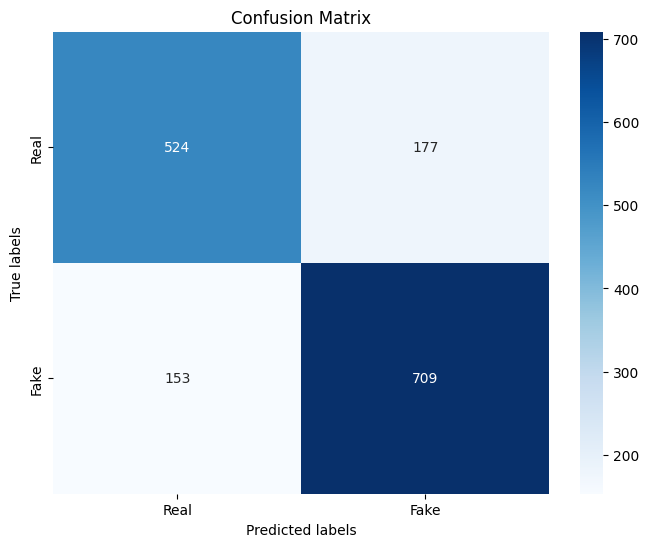

In [30]:
plt.figure(figsize=(8, 6))
# Class names according to the label encoding mapping
class_names = ['Real', 'Fake']
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()